## Importing libraries

In [3]:
import numpy as np 
import pandas as pd 

import re    #for regural expressions->finding patterns in text, replacing text, extracting specific words
import nltk  #natural language toolkit->tokenizing text

#for converting the text into numeric
from sklearn.feature_extraction.text import TfidfVectorizer

#data
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#modeling algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
###neural network

#plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from wordcloud import WordCloud

from nltk.corpus import stopwords

# Loading the dataset

In [4]:
filename="/kaggle/input/datasets/mexwell/fake-reviews-dataset/fake reviews dataset.csv"
data=pd.read_csv(filename)
data.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


## Data preparation
### Checking for missing values

In [6]:
data.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

No missing values. :)

## Deleting unneeded columns  
Since we are checking whether the text is Computer or Human written, the rating column only decribes sentiment. Also the category column is not needed.
They could introduce dataset bias and distract the models from learning textual characteristics.

In [7]:
data=data.drop(columns=["category","rating"])

In [8]:
data["label"].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

## Data analysis

(array([0, 1]), [Text(0, 0, 'CG'), Text(1, 0, 'OR')])

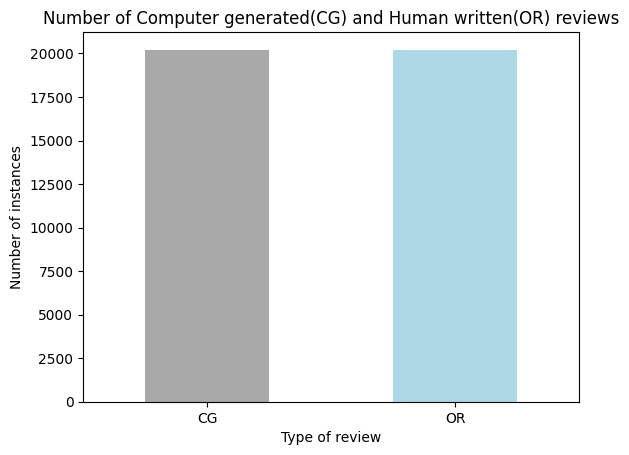

In [9]:
reviews_counts=data['label'].value_counts()

reviews_counts.plot(kind='bar', color=['darkgray','lightblue'])
plt.xlabel("Type of review")
plt.ylabel("Number of instances")
plt.title("Number of Computer generated(CG) and Human written(OR) reviews")
plt.xticks(rotation=0)

Same number of samples in both types of reviews.

## Cleaning the data
All text to lowercase, remove punctuation, remove numbers, remove extra spaces and tokenizing(spliting the data into words, and then joining back because TF-IDF needs the sentences as string

In [13]:
#stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+', '',text)    #remove numbers
    text=re.sub(r'[^\w\s]', '',text)  #remove punctuaiton
    words=text.split()   #tokenize

    #words=[word for word in words if word not in stop_words]
    
    text=" ".join(words)  #join back into sentence
    return text

#### Apply the cleaning to all reviews

In [14]:
data['reviews']=data['text_'].apply(clean_text)

Data after cleaning:

In [15]:
print(data[['text_','reviews']].head())

                                               text_  \
0  Love this!  Well made, sturdy, and very comfor...   
1  love it, a great upgrade from the original.  I...   
2  This pillow saved my back. I love the look and...   
3  Missing information on how to use it, but it i...   
4  Very nice set. Good quality. We have had the s...   

                                             reviews  
0  love this well made sturdy and very comfortabl...  
1  love it a great upgrade from the original ive ...  
2  this pillow saved my back i love the look and ...  
3  missing information on how to use it but it is...  
4  very nice set good quality we have had the set...  


### Converting the labels into numeric values
0-Human written original reviews(OR)  
1-Computer generated reviews(CG)

In [10]:
print(data['label'].unique())

['CG' 'OR']


In [11]:
data['label']=data['label'].map({
    'OR':0,
    'CG':1
})

In [12]:
data.head()

,label,text_
0,1,"Love this! Well made, sturdy, and very comfor..."
1,1,"love it, a great upgrade from the original. I..."
2,1,This pillow saved my back. I love the look and...
3,1,"Missing information on how to use it, but it i..."
4,1,Very nice set. Good quality. We have had the s...


## Splitting dataset

Split data into train/validation/test set  
60% train, 20% validation, 20% test 

In [21]:
X=data['reviews']
y=data['label']

#first split
X_temp, X_test, y_temp, y_test=train_test_split(
    X,y,test_size=0.2, random_state=42, stratify=y
)

#second split
X_train, X_val, y_train, y_val=train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)